# Virtual Spatial Transcriptomics from H&E Images

Click to open in: \[[GitHub](https://github.com/TissueImageAnalytics/tiatoolbox/blob/develop/examples/inference-pipelines/deepspotm.ipynb)\]\[[Colab](https://colab.research.google.com/github/TissueImageAnalytics/tiatoolbox/blob/develop/examples/inference-pipelines/deepspotm.ipynb)\]



## About this notebook

This jupyter notebook can be run on any computer with a standard browser and no prior installation of any programming language is required. It can run remotely over the Internet, free of charge, thanks to Google Colaboratory. To connect with Colab, click on one of the two blue checkboxes above. Check that "colab" appears in the address bar. You can right-click on "Open in Colab" and select "Open in new tab" if the left click does not work for you. Familiarize yourself with the drop-down menus near the top of the window. You can edit the notebook during the session, for example substituting your own image files for the image files used in this demo. Experiment by changing the parameters of functions. It is not possible for an ordinary user to permanently change this version of the notebook on GitHub or Colab, so you cannot inadvertently mess it up. Use the notebook's File Menu if you wish to save your own (changed) notebook.

To run the notebook on any platform, except for Colab, set up your Python environment, as explained in the
[README](https://tia-toolbox.readthedocs.io/en/latest/installation.html) file.



## About this demo

Spatial transcriptomics measures gene expression while keeping the position of each
measurement on the tissue, but it is expensive and is not part of routine practice.
Predicting that signal from an H&E slide gives a cheap approximation of it, over the
whole slide, from an image that has already been scanned.

In this example notebook, we show how you can use
[DeepSpot-M](https://huggingface.co/ratschlab/DeepSpotM) (Nonchev et al., medRxiv 2026)
to predict spatial gene expression across a whole-slide image. DeepSpot-M maps a
224x224 H&E tile to transcriptome-wide expression. It tokenizes the tile with a
LoRA-adapted Midnight backbone and lets each gene attend to those tokens through a
cross-attention decoder. Genes are represented as queryable embeddings rather than as
fixed output units, so a single model covers a panel of about 19,000 genes and can be
asked for genes it did not see during training.

Because DeepSpot-M reads an image tile and returns one vector per tile, it fits the
`DeepFeatureExtractor` contract used elsewhere in TIAToolbox, with one difference in
how the output is read: each "feature" column is a named gene. Running it over a WSI
therefore yields an `(n_tiles, n_genes)` expression matrix and the matching tile
coordinates.

We predict three markers on a colon adenocarcinoma slide, chosen so that each one
reports on a different tissue compartment:

| Gene   | Marks                                |
| ------ | ------------------------------------ |
| EPCAM  | epithelium, and so the tumour glands |
| PTPRC  | leukocytes, the immune infiltrate    |
| COL1A1 | collagen, the stroma                 |

Restricting the request to a small panel computes only those gene queries, which is
faster and keeps the saved matrix small. The same call with `genes=None` returns the
full panel.



## Setting up the environment

### TIAToolbox and dependencies installation

You can skip the following cell if 1) you are not using the Colab plaform or 2) you are using Colab and this is not your first run of the notebook in the current runtime session. If you nevertheless run the cell, you may get an error message, but no harm will be done. On Colab the cell installs `tiatoolbox`, and other prerequisite software. Harmless error messages should be ignored. Outside Colab , the notebook expects `tiatoolbox` to already be installed. (See the instructions in [README](https://tia-toolbox.readthedocs.io/en/latest/installation.html).)

DeepSpot-M ships as the separate `deepspotm` package, which TIAToolbox imports lazily,
so it is installed here alongside the toolbox.



In [ ]:
%%bash
apt-get -y install libopenjp2-7-dev libopenjp2-tools libpixman-1-dev | tail -n 1
pip install uv
uv pip install git+https://github.com/TissueImageAnalytics/tiatoolbox.git@develop | tail -n 1
uv pip install deepspotm | tail -n 1
echo "Installation is done."

**IMPORTANT**: If you are using Colab and you run the cell above for the first time, note that you need to restart the session. To do this, you can either click on the message that appears above this cell, or use Colab's Runtime menu *"Runtime→Restart session"*. After restarting the Runtime, you can use the notebook normally, for example using *Runtime→Run All*, or running the cells one-by-one.



### Importing related libraries

We import some standard Python modules, and also the Python module `wsireader` (see [details](https://tia-toolbox.readthedocs.io/en/latest/_autosummary/tiatoolbox.wsicore.wsireader.WSIReader.html)) written by the TIA Centre team.



In [9]:
"""Import modules required to run the Jupyter notebook."""

# Clear logger to use tiatoolbox.logger
import logging

if logging.getLogger().hasHandlers():
    logging.getLogger().handlers.clear()

import shutil
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import zarr
from huggingface_hub import get_token, hf_hub_download, notebook_login

from tiatoolbox import logger
from tiatoolbox.models.architecture.deepspotm import DeepSpotM
from tiatoolbox.models.engine.deep_feature_extractor import DeepFeatureExtractor
from tiatoolbox.models.engine.io_config import IOPatchPredictorConfig
from tiatoolbox.wsicore.wsireader import WSIReader

mpl.rcParams["figure.dpi"] = 160  # for high resolution figure in notebook
mpl.rcParams["figure.facecolor"] = "white"  # To make sure text is visible in dark mode

### GPU or CPU runtime

Processes in this notebook can be accelerated by using a GPU. Therefore, whether you are running this notebook on your system or Colab, you need to check and specify appropriate [device](https://pytorch.org/docs/stable/tensor_attributes.html#torch.device) e.g., "cuda" or "cpu" whether you are using GPU or CPU. In Colab, you need to make sure that the runtime type is set to GPU in the *"Runtime→Change runtime type→Hardware accelerator"*. If you are *not* using GPU, consider changing the `device` flag to `cpu` value, otherwise, some errors will be raised when running the following cells.



In [ ]:
device = "cuda"  # Choose appropriate device, "cuda" or "cpu" or "mps"
WORKERS = 0
if device == "cuda":
    WORKERS = 8

### Removing leftovers from previous runs

The cell below removes a `tmp` directory that may have been generated in a previous run.



In [11]:
warnings.filterwarnings("ignore")
save_dir = Path("./tmp/")


def rmdir(dir_path: Path) -> None:
    """Helper function to delete directory."""
    if dir_path.is_dir():
        shutil.rmtree(dir_path)
    logger.info("Deleting %s", dir_path)


rmdir(save_dir)  # remove `save_dir` if it exists from a previous run
save_dir.mkdir()
logger.info(
    "Creating new directory %s for downloaded and newly created files.",
    save_dir,
)

### Access to the model weights

The DeepSpot-M weights are released for non-commercial research use and are gated on
the Hugging Face Hub. Accept the terms once on the
[model page](https://huggingface.co/ratschlab/DeepSpotM), then authenticate below. The
cell is a no-op if a token is already stored, so it does not prompt on a repeat run.

You can skip this step if you have downloaded the weights manually from [model page](https://huggingface.co/ratschlab/DeepSpotM) and you plan to use the local weights.



In [ ]:
if get_token() is None:
    notebook_login()
else:
    logger.info("A Hugging Face token is already available.")

### Downloading the required files

We download, over the internet, image files used for the purpose of this notebook. In particular, we download a whole slide image of cancerous colon tissue to highlight how the pipeline works.



In [12]:
REPO_ID = "TIACentre/TIAToolBox_Remote_Samples"
REPO_TYPE = "dataset"
sample_wsi_path = hf_hub_download(
    repo_id=REPO_ID,
    subfolder="sample_wsis",
    filename="wsi4_12k_12k.svs",
    repo_type=REPO_TYPE,
    local_dir=save_dir,
)
logger.info("Downloaded sample WSI: %s", sample_wsi_path)

sample_wsis/wsi4_12k_12k.svs:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

## Predicting spatial gene expression

We first create the model. `source` selects which of the pretrained gene-embedding
spaces is used to build the gene queries, and `genes` restricts the prediction to our
marker panel.

We then describe the input geometry with an `IOPatchPredictorConfig`. DeepSpot-M expects
224x224 tiles, and we read them at 0.5 microns per pixel, which is roughly 20x objective
magnification. Setting `stride_shape` equal to `patch_input_shape` tiles the slide
without overlap.

Finally we pass the model to a `DeepFeatureExtractor` and run it over the slide with
`patch_mode=False`. A tissue mask is generated automatically, so background tiles are
skipped rather than predicted.



In [ ]:
genes = ["EPCAM", "PTPRC", "COL1A1"]

model = DeepSpotM(source="scgpt", genes=genes)

wsi_ioconfig = IOPatchPredictorConfig(
    input_resolutions=[{"units": "mpp", "resolution": 0.5}],
    patch_input_shape=[224, 224],
    stride_shape=[224, 224],
)

extractor = DeepFeatureExtractor(
    model=model,
    batch_size=8,
    num_workers=WORKERS,
)

In [ ]:
output = extractor.run(
    images=[sample_wsi_path],
    ioconfig=wsi_ioconfig,
    patch_mode=False,
    device=device,
    overwrite=True,
    save_dir=save_dir / "deepspotm_output",
    output_type="zarr",
)

### Reading the predicted expression matrix

The engine writes a zarr store holding two arrays. `features` is the
`(n_tiles, n_genes)` expression matrix, in the order the genes were requested, and
`coordinates` holds the bounding box of each tile at the processing resolution. Values
are in the log1p counts-per-million space the model was trained in, so they are
comparable between tiles of the same slide rather than being absolute counts.



In [15]:
predictions = zarr.open(output[Path(sample_wsi_path)], mode="r")
expression = np.asarray(predictions["features"])
coordinates = np.asarray(predictions["coordinates"])

logger.info("Predicted expression matrix: %s", expression.shape)
logger.info("Tile coordinates: %s", coordinates.shape)

## Visualizing the results

Each row of the matrix belongs to a tile whose position on the slide we know, and the
tiles were taken on a regular grid, so the predictions can be reshaped into one small
image per gene and laid back over the slide. Drawing each tile over its whole footprint,
instead of as a point at its centre, turns the per-tile values into a heatmap. Tiles that
the tissue mask skipped are left transparent, and the slide is shown in grey underneath
so the colours stay readable.



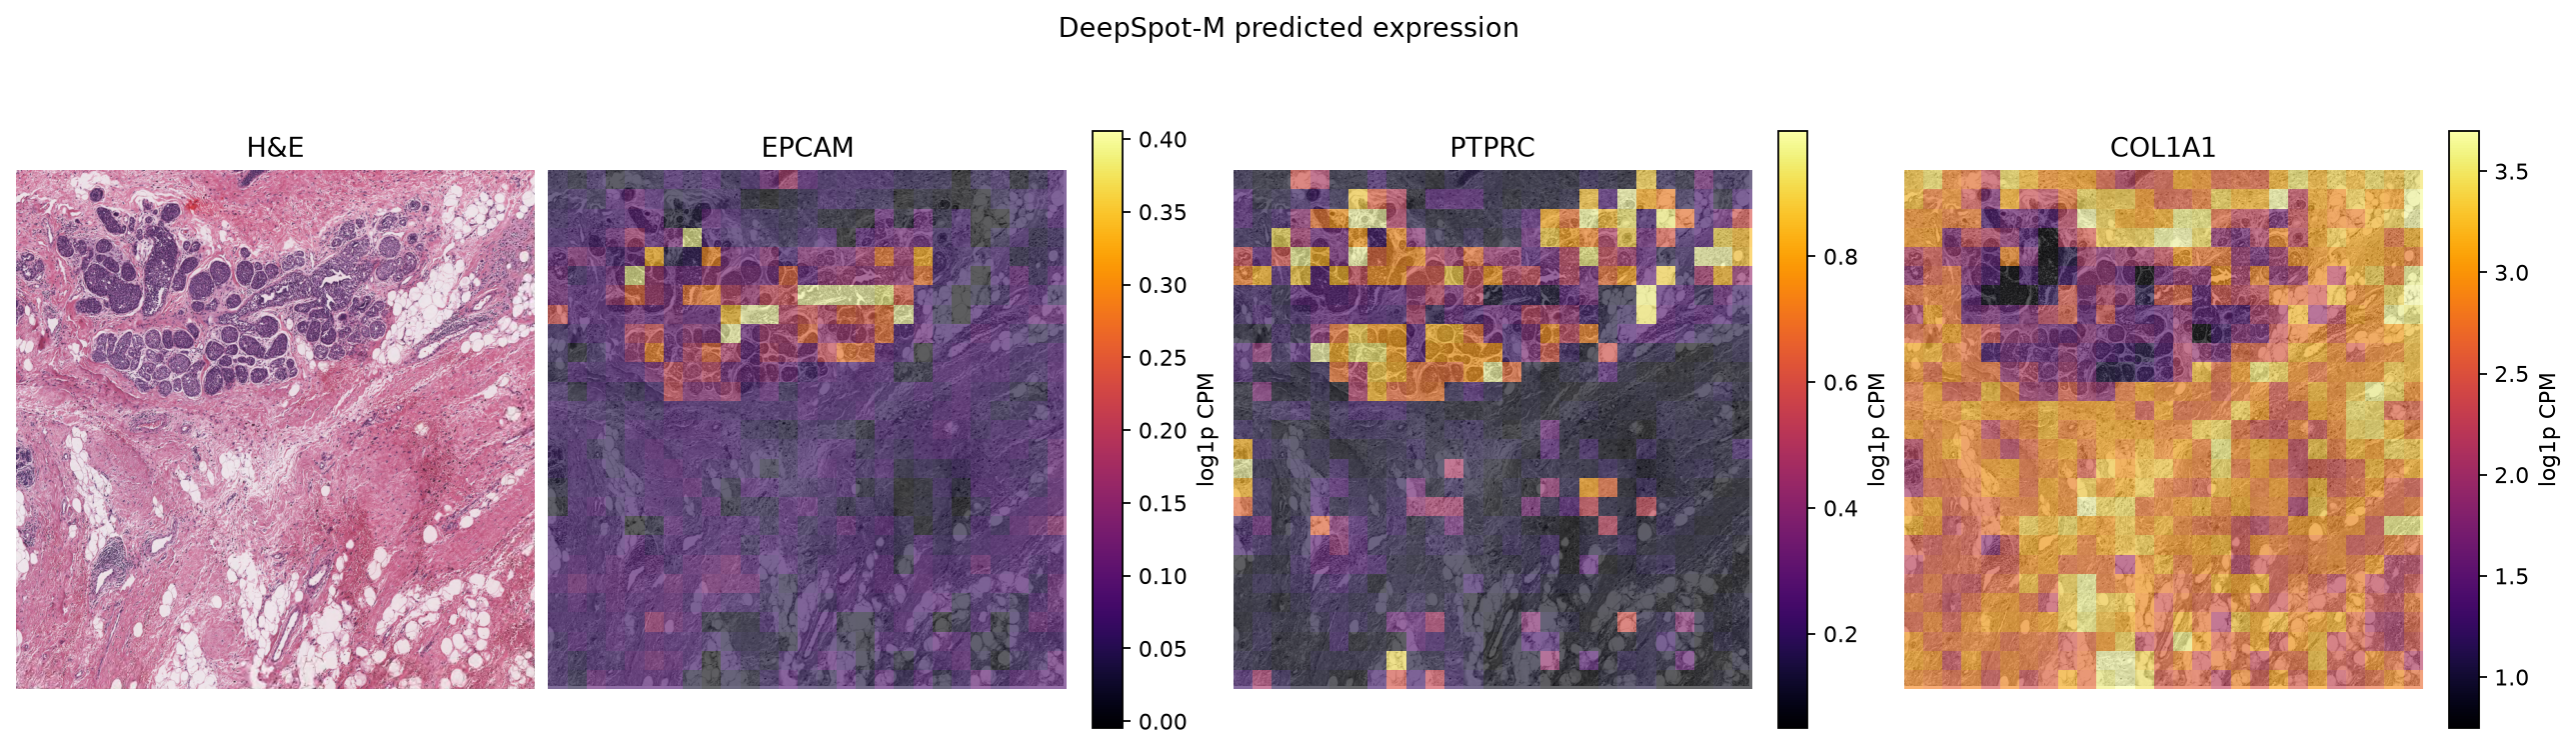

In [16]:
overview_resolution = 4  # the resolution at which we visualize the predictions
overview_unit = "mpp"

wsi = WSIReader.open(sample_wsi_path)
wsi_overview = wsi.slide_thumbnail(
    resolution=overview_resolution,
    units=overview_unit,
)

# The tiles sit on a regular lattice, so each prediction can be put back into the grid
# cell it came from, which turns a gene column into a small image.
stride_x, stride_y = 224, 224
left, top = coordinates[:, 0].min(), coordinates[:, 1].min()
columns = np.round((coordinates[:, 0] - left) / stride_x).astype(int)
rows = np.round((coordinates[:, 1] - top) / stride_y).astype(int)
grid_shape = (rows.max() + 1, columns.max() + 1)

# Where that lattice falls in the thumbnail, as (left, right, bottom, top), so each
# grid cell is drawn over the tissue it was predicted from.
scale = overview_resolution / 0.5
extent = (
    left / scale,
    (left + grid_shape[1] * stride_x) / scale,
    (top + grid_shape[0] * stride_y) / scale,
    top / scale,
)

# A grey copy of the slide keeps the tissue visible under the colour maps.
overview_grey = wsi_overview.mean(axis=-1)

fig, axes = plt.subplots(
    1,
    len(genes) + 1,
    figsize=(4 * (len(genes) + 1), 5),
    layout="constrained",
)
axes[0].imshow(wsi_overview)
axes[0].set_title("H&E")
axes[0].axis("off")

for ax, gene, values in zip(axes[1:], genes, expression.T, strict=True):
    heat = np.full(grid_shape, np.nan)  # tiles skipped by the mask stay empty
    heat[rows, columns] = values

    ax.imshow(overview_grey, cmap="gray")
    heatmap = ax.imshow(
        heat,
        extent=extent,
        cmap="inferno",
        interpolation="nearest",
        alpha=np.where(np.isnan(heat), 0.0, 0.6),
        vmin=np.nanquantile(heat, 0.01),
        vmax=np.nanquantile(heat, 0.99),
    )
    ax.set_title(gene)
    ax.axis("off")
    fig.colorbar(heatmap, ax=ax, shrink=0.8, label="log1p CPM")

fig.suptitle("DeepSpot-M predicted expression")
plt.show()

The three markers separate the slide into the compartments they report on. EPCAM is
highest over the epithelial glands, COL1A1 follows the stroma between them, and PTPRC
picks out the denser immune regions. A gene that is not expressed in this tissue stays
flat everywhere, which is the expected behaviour and a useful sanity check.

These maps are predictions from morphology, not measurements. They are useful for
finding structure and for prioritizing where to spend a real assay, and the values
should not be read as calibrated molecular counts.



## Predicting the full transcriptome

Passing `genes=None` predicts the full panel of about 19,000 genes instead of a chosen
few. The call is otherwise identical, and the output matrix becomes
`(n_tiles, n_genes)` with `model.gene_names` labelling the columns. It is worth noting
that this is a much larger array to compute and store, so the marker-panel form above is
usually the better starting point.

```python
model = DeepSpotM(source="scgpt")  # every gene in the panel
extractor = DeepFeatureExtractor(model=model, batch_size=32, num_workers=WORKERS)
output = extractor.run(
    images=[wsi_file_name],
    ioconfig=wsi_ioconfig,
    patch_mode=False,
    device=device,
    save_dir=save_dir / "deepspotm_full_output",
    output_type="zarr",
)
```



## Conclusion

We ran DeepSpot-M over a whole-slide image through the `DeepFeatureExtractor` engine and
recovered a spatial expression map for three marker genes, using the same engine call
that drives the other tile encoders in TIAToolbox. Swapping the gene list, or dropping it
to take the whole panel, changes what is predicted without changing the pipeline.

If you use DeepSpot-M, please cite the paper and observe the licence on the weights,
which covers non-commercial research use.

- DeepSpot-M: [model](https://huggingface.co/ratschlab/DeepSpotM) and
  [code](https://github.com/ratschlab/DeepSpotM)
- Nonchev et al., *A multimodal foundation model for transcriptome-wide virtual spatial
  transcriptomics from histology*, medRxiv 2026,
  [10.64898/2026.06.19.26356060](https://www.medrxiv.org/content/10.64898/2026.06.19.26356060v1)

